In [210]:
using LinearAlgebra
using LinearOperators
using SparseArrays

In [211]:
# consider arbitrary system Ax=b coming from the discretization of a PDE

#= FD
1) build laplace matrix
2) laplae as discrete operator, full vectors
3) ??
=#

In [212]:
function get_laplace_op_matrix(n)
	off = ones(n-1)
	diag = ones(n)
	spdiagm(-1 => off, 0 => -2diag, 1 => off)
end

get_laplace_op_matrix (generic function with 1 method)

In [213]:
L = get_laplace_op_matrix(7)
E = sparse(I, 7,7)
kron(E,L) + kron(L,E)

49×49 SparseMatrixCSC{Float64, Int64} with 217 stored entries:
⎡⠻⣦⡀⠈⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⡀⠈⠻⢆⡀⠈⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠈⠢⡀⠈⠻⣦⡀⠈⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠈⠢⡀⠈⠛⣤⡀⠈⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠈⠢⡀⠈⠻⣦⡀⠈⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠈⠢⡀⠈⠱⣦⡀⠈⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⡀⠈⠻⣦⠀⠈⠢⡀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⡀⠀⠻⣦⡀⠈⠢⡀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⡀⠈⠻⢆⡀⠈⠢⡀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⡀⠈⠻⣦⡀⠈⠢⡀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⡀⠈⠛⣤⡀⠈⠂⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⡀⠈⠻⣦⡀⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠀⠀⠈⠁⎦

In [214]:
# L
# E L, L E
# E E L, E L E, L E E
# E E E L, E E L E, E L E E, L E E E
# (E E E L), (E E L) (E), (E L) (E E), (L) (E E E)
# E ... E L = L of size n^(k+1) if E is there k times
n = 4
d = 3

L_full = get_laplace_op_matrix(n^d)
for k in 1:(d-1)
	L = get_laplace_op_matrix(n^(d-k))
	size = n^k
	E = sparse(I, size, size)
	L_full += kron(L, E)
end
L_full

64×64 SparseMatrixCSC{Float64, Int64} with 406 stored entries:
⎡⠻⣦⡑⢄⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠑⢌⠻⣦⡑⢄⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠑⢌⠻⣦⡑⢄⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠑⢌⠻⣦⡑⢄⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠑⢄⠀⠀⠀⠀⠑⢌⠻⣦⡑⢄⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠑⢄⠀⠀⠀⠀⠑⢌⠻⣦⡑⢄⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠑⢌⠻⣦⡑⢄⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠑⢌⠻⣦⡑⢄⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠑⢌⠻⣦⡑⢄⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠑⢌⠻⣦⡑⢄⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠑⢌⠻⣦⡑⢄⠀⠀⠀⠀⠑⢄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠑⢌⠻⣦⡑⢄⠀⠀⠀⠀⠑⢄⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠑⢌⠻⣦⡑⢄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠑⢌⠻⣦⡑⢄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠑⢌⠻⣦⡑⢄⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠑⢌⠻⣦⎦

In [215]:
#Matrix(L_full)

## define RHS and solve using different methods

$\Delta u = f \:\:\text{on}\:\:\Omega$

$u = g \:\:\text{on}\:\:\partial\Omega$

supp 1D:

$ \partial u / \partial x \approx \frac{u(x+h/2) - u(x-h/2)}{h}$

$\Delta u(x) \approx \frac{u(x+h) - 2u(x) + u(x-h)}{h^2}$

$ u_{i-1} - 2u_i + u_{i+1} = h^2 f_i$

$ i = 0,1,...,n,n+1 $

boundary: $\:i=0, \:i=n+1 $

we know $\:u_0, \:u_{n+1}\:$ from BC

we need $n$ equation for $n$ unknowns ($u_1,...,u_n$)

$ u_0 - 2u_1 + u_2 = h^2 f_1 $

$ u_1 - 2u_2 + u_3 = h^2 f_2 $

...

$ u_{n-2} - 2u_{n-1} + u_{n} = h^2 f_{n-1} $

$ u_{n-1} - 2u_n + u_{n+1} = h^2 f_n $

we get

$ L U = F $

where
- $L$ matrix of size $n \times n$
- $U = (u_1, u_2, ..., u_{n-1}, u_n)$
- $F = h^2(f_1, f_2, ..., f_{n-1}, f_n) - (u_0, 0, ..., 0, u_{n+1})$

In [216]:
n = 64

64

In [217]:
h = 1 / (n+1)

0.015384615384615385

In [218]:
function u_analytic_fun(x)
    # u'' = -pi^2 u = f
    sin.(pi*x)
end

function f_fun(x)
    -pi^2 * sin.(pi*x)
end

f_fun (generic function with 1 method)

In [219]:
using IterativeSolvers

Jacobi, Gauss-Seidel :
- https://iterativesolvers.julialinearalgebra.org/stable/linear_systems/stationary/

CG :
- https://iterativesolvers.julialinearalgebra.org/stable/linear_systems/cg/



In [220]:
L = get_laplace_op_matrix(n)
#Matrix(L)

64×64 SparseMatrixCSC{Float64, Int64} with 190 stored entries:
⎡⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⡀⠀⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠻⣦⎦

In [221]:
grid_points = collect(range(h,1-h, length=n));

In [222]:
h, grid_points[1]

(0.015384615384615385, 0.015384615384615385)

In [223]:
f = f_fun(grid_points);

In [224]:
F = h^2 * f;

In [232]:
U_jacobi = jacobi(L, F, maxiter=1000)
U_gs = gauss_seidel(L, F, maxiter=1000)
U_dir = L \ F

64-element Vector{Float64}:
 0.048322785632855796
 0.09653271116081302
 0.1445171800689775
 0.19216412240683722
 0.2393622565328245
 0.28600134901774615
 0.3319724721000652
 0.3771682580917349
 0.4214831501404092
 0.4648136487623627
 0.5070585535703301
 0.5481191996317
 0.5878996879050367
 ⋮
 0.5481191996316979
 0.5070585535703281
 0.46481364876236086
 0.4214831501404075
 0.37716825809173327
 0.33197247210006375
 0.28600134901774493
 0.23936225653282348
 0.1921641224068364
 0.14451718006897685
 0.09653271116081258
 0.04832278563285558

In [226]:
U_analytic = u_analytic_fun(grid_points);

In [227]:
using CairoMakie
CairoMakie.activate!()
#GLMakie.activate!(title = "Custom title", fxaa = false)

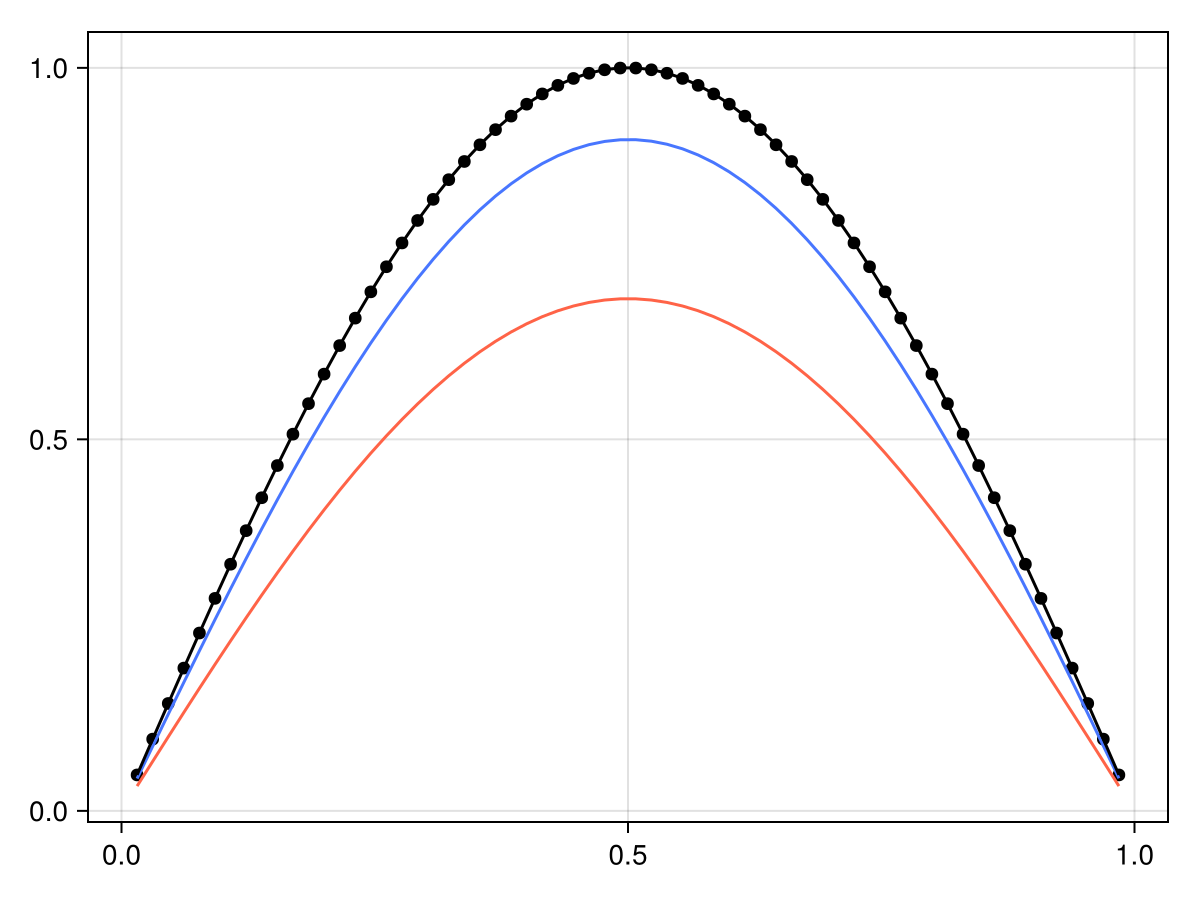

In [233]:
scatter(grid_points, U_analytic, color=:gray0)
lines!(grid_points, U_jacobi, color=:tomato)
lines!(grid_points, U_gs, color=:royalblue1)
lines!(grid_points, U_dir, color=:gray0)
current_figure()

In [229]:
#n_trials = 8
#n_mult = 8
#max_jacobi = zeros(n_trials)
#max_gs = zeros(n_trials)
#max_direct = zeros(n_trials)
#
#for i in 1:n_trials
#    n = n_mult*i
#    h = 1/(n+1)
#    grid_points = collect(range(h,1-h, length=n))
#    L = get_laplace_op_matrix(n)
#    F = h^2 * f_fun(grid_points)
#    U_jacobi = jacobi(L, F)
#    U_gs = gauss_seidel(L, F; maxiter=100)
#    U_direct = L \ F
#
#    max_jacobi[i] = maximum(U_jacobi)
#    max_gs[i] = maximum(U_gs)
#    max_direct[i] = maximum(U_direct)
#end